#Сборный Проект — 3,4

**Описание проекта:**

Вы — специалист по Data Science в каршеринговой компании. Вам поступил заказ: нужно создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения. Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.
Идея создания такой системы находится в стадии предварительного обсуждения и проработки. Чёткого алгоритма работы и подобных решений на рынке ещё не существует.

**Текущая задача** — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

**Идея решения задачи от заказчика:**

    Создать модель предсказания ДТП (целевое значение — at_fault (виновник) в таблице parties)
     
        Для модели выбрать тип виновника — только машина (car).
        Выбрать случаи, когда ДТП привело к любым повреждениям транспортного средства, кроме типа SCRATCH (царапина).
        Для моделирования ограничиться данными за 2012 год — они самые свежие.
        Обязательное условие — учесть фактор возраста автомобиля.
    На основе модели исследовать основные факторы ДТП.
    Понять, помогут ли результаты моделирования и анализ важности факторов ответить на вопросы:
     
        Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
        Какие ещё факторы нужно учесть?
        Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?

Заказчик предлагает вам поработать с базой данных по происшествиям и сформировать свои идеи создания такой системы.

## 1. Загрузка данных

Установим и объявим необходимые библиотеки, подключимся к базе данных PostgreSQL, проведём первичное исследование таблиц.

In [1]:
!pip install psycopg2-binary
!pip install -U ydata-profiling
!pip install phik
!pip install shap
!pip install imbalanced-learn

In [2]:
#!pip install --upgrade matplotlib seaborn # - для jupiter notebook: в Google colab все модули и библиотеки импортируются без проблем и ошибок.

In [3]:
import psycopg2
from psycopg2 import sql

#from google.colab import files #поставить решётку перед загрузкой в jupiter
#from IPython.display import Image, display #поставить решётку перед загрузкой в jupiter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import shap

import ydata_profiling as pp
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from phik import phik_matrix
from phik.report import plot_correlation_matrix

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, log_loss
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
# Установка конфигурации базы данных
db_config = {
    'user': 'praktikum_student',                          # имя пользователя,
    'pwd': 'Sdf4$2;d-d30pp',                              # пароль,
    'host':                                               # хост, данные скрыты
    'port': 6432,                                         # порт подключения,
    'db': 'data-science-vehicle-db'                       # название базы данных,
}

# Подключение к базе данных
try:
    connection = psycopg2.connect(
        user=db_config['user'],
        password=db_config['pwd'],
        host=db_config['host'],
        port=db_config['port'],
        database=db_config['db']
    )
    print("Подключение к базе данных произведено успешно!")

    # Открытие курсора
    cursor = connection.cursor()

    # 1. Проверка общего количества таблиц
    query = """
    SELECT COUNT(*) AS total_tables
    FROM information_schema.tables
    WHERE table_schema = 'public';
    """
    cursor.execute(query)
    total_tables = cursor.fetchone()[0]
    print(f"Общее количество таблиц: {total_tables}")

    # 2. Проверка количества записей в таблицах
    # Получение имён таблиц
    cursor.execute("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public';
    """)
    tables = cursor.fetchall()

    # Словарь для хранения количества строк в таблицах
    row_counts = {}

    # Динамический SQL для подсчета строк
    for table in tables:
        table_name = table[0]
        query = f'SELECT COUNT(*) FROM "{table_name}";'  # Использование двойных кавычек для защиты имен таблиц
        cursor.execute(query)
        row_count = cursor.fetchone()[0]
        row_counts[table_name] = row_count

    # Вывод результатов
    print("Количество записей в таблицах:")
    for table_name, count in row_counts.items():
        print(f"Таблица: {table_name}, Количество записей: {count}")

    # 3. Проверка наличия внешнего ключа
    query = """
    SELECT
        conname AS constraint_name,
        conrelid::regclass AS table_name,
        a.attname AS column_name,
        confrelid::regclass AS referenced_table,
        af.attname AS referenced_column
    FROM
        pg_constraint AS c
    JOIN
        pg_attribute AS a ON a.attnum = ANY(c.conkey) AND a.attrelid = c.conrelid
    JOIN
        pg_attribute AS af ON af.attnum = ANY(c.confkey) AND af.attrelid = c.confrelid
    WHERE
        c.contype = 'f';
    """
    cursor.execute(query)
    foreign_keys = cursor.fetchall()

    print("Информация о внешнем ключе:")
    for fk in foreign_keys:
        print(f"Ограничение: {fk[0]}, Таблица: {fk[1]}, Столбец: {fk[2]}, Ссылается на таблицу: {fk[3]}, Ссылается на столбец: {fk[4]}")

except Exception as e:
    print("Ошибка при подключении к базе данных:", e)

### Промежуточные выводы:

* количество таблиц соответствует условию задачи;
* все таблицы имеют набор данных;
* имеется общий ключ для связи таблиц - `case_id` в таблице `case_ids`.


Для наглядности дополнительно отобразим структуру базы данных:

In [5]:
'''#Для работы в Google colab

uploaded = files.upload()

for filename in uploaded.keys():
    display(Image(filename=filename))'''

## Статистический анализ факторов ДТП

Выясним, в какие месяцы происходит наибольшее количество аварий. Проанализируем весь период наблюдений.

In [6]:
query = """
SELECT CAST(EXTRACT(MONTH FROM collision_date) AS integer) AS month,
        COUNT(*) AS count_collision
FROM collisions
GROUP BY month
ORDER BY month;
"""

cursor.execute(query)
rows = cursor.fetchall()
column_names = [desc[0] for desc in cursor.description]

In [7]:
# Преобразуем в DataFrame
df = pd.DataFrame(rows, columns=column_names)

# Выводим полученный DataFrame
display(df)

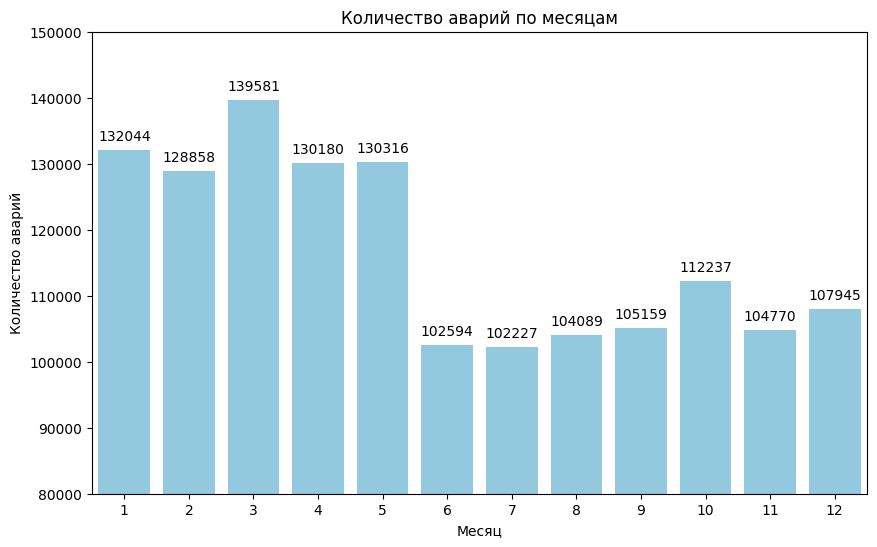

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='count_collision', data=df, color='skyblue')

# Настройка осей и заголовка
plt.xlabel('Месяц')
plt.ylabel('Количество аварий')
plt.title('Количество аварий по месяцам')
plt.ylim(80000, 150000)

# Отображение значений над столбцами
for index, value in enumerate(df['count_collision']):
    plt.text(index, value + 1000, str(value), ha='center', va='bottom')

# Отображение диаграммы
plt.show()

### Промежуточный вывод:

Наибольшее количество аварий происходит в марте, январе, мае, апреле и феврале.
Вероятно, это связано с погодными условиями (снег, гололёд), праздниками (вождение в нетрезвом виде).

## Задачи для коллег

Подготовим аналитические задачи для коллег:

1. Проведите анализ серьёзности повреждений транспортного средства, исходя из трезвости участника ДТП (связать collisions и parties);
2. Проведите анализ серьёзности повреждений транспортного средства, исходя из типа кузова автомобиля (связать collisions и vehicles);
3. По каким регионам наблюдается больше аварий, а по каким - меньше (таблица collisions);
4. По каким категориям нарушения наблюдается больше аварий, а по каким - меньше (таблица collisions);
5. Проведите анализ серьёзности повреждений транспортного средства, исходя из возраста автомобиля (связать collisions и vehicles);
6. Проведите анализ физического состояния и трезвости участника ДТП (таблица parties).

Решим первые две задачи с помощью SQL-запросов.

In [9]:
query = """
SELECT COLLISION_DAMAGE AS collision_damage,
        PARTY_SOBRIETY AS party_sobriety
FROM collisions AS c
INNER JOIN parties AS p ON c.case_id = p.case_id;
"""

cursor.execute(query)
rows = cursor.fetchall()
column_names = [desc[0] for desc in cursor.description]

In [10]:
# Преобразуем в DataFrame
df = pd.DataFrame(rows, columns=column_names)

# Выводим полученный DataFrame
display(df)

In [11]:
# Заполним пропуски заглушкой 'impairment unknown'
display(df['party_sobriety'].unique())
df['party_sobriety'] = df['party_sobriety'].fillna('impairment unknown')

In [12]:
pvt = pd.pivot_table(df, index='collision_damage', columns='party_sobriety', aggfunc='size')
display(pvt)

In [13]:
# Создание субграфиков
fig = make_subplots(
    rows=1,
    cols=len(pvt.index),
    specs=[[{'type': 'pie'}] * len(pvt.index)],
    subplot_titles=pvt.index
)

# Добавление круговых диаграмм для каждой категории
for i, damage_type in enumerate(pvt.index):
    values = pvt.loc[damage_type]
    total_count = values.sum()  # Общая сумма значений

    # Сортируем значения по убыванию
    sorted_values = values.sort_values(ascending=False)
    sorted_labels = sorted_values.index

    fig.add_trace(go.Pie(
        labels=sorted_labels,
        values=sorted_values,
        name=damage_type,
        textinfo='percent',  # Отображаем только проценты
        pull=[0.1, 0],  # Выдвигает первую секцию (трезвые) для акцента
        sort=True,  # Сортировка секторов
        direction='clockwise'  # Положение секторов по часовой стрелке
    ), row=1, col=i + 1)

    # Добавление аннотации снизу диаграммы с фиксированными координатами
    fig.add_annotation(
        x=i + 1,  # Позиция по оси x, колонка i + 1
        y=-0.12,  # Позиция по оси y (поставим ниже)
        text=f"Количество значений: {total_count}",
        showarrow=False,
        font=dict(size=12),
        xref='x',  # Оси X
        yref='paper'  # Используем 'paper' для позиционирования
    )

# Настройка общего заголовка, расположения легенды и скрытие осей
fig.update_layout(
    title_text="Соотношение трезвых и пьяных водителей по типу повреждения автомобиля в аварии",
    title_x=0.5,  # Центрируем заголовок
    height=700,  # Задаем высоту, чтобы было больше места для подписей
    width=1500,  # Задаем ширину, чтобы большие диаграммы поместились
    margin=dict(t=50, b=150, l=50, r=50),  # Настройка отступов для улучшения области графиков
    legend=dict(x=0.5, y=-0.3, xanchor='center', yanchor='top', orientation='h')  # Позиционируем легенду снизу
)

# Показываем график
fig.show()

### Промежуточный вывод:

По графикам видно, что в ДТП, которые привели к полному разрушению автомобиля, доля пьяных водителей выше всего **(>20%)**. Меньше всего (<4-6%) - в ДТП с царапинами и небольшими повреждениями.

Вторая задача:

In [14]:
query = """
SELECT COLLISION_DAMAGE AS collision_damage,
        VEHICLE_TYPE AS vehicle_type
FROM collisions AS c
INNER JOIN vehicles AS v ON c.case_id = v.case_id;
"""

cursor.execute(query)
rows = cursor.fetchall()
column_names = [desc[0] for desc in cursor.description]

In [15]:
# Преобразуем в DataFrame
df = pd.DataFrame(rows, columns=column_names)

# Выводим полученный DataFrame
display(df)

In [16]:
pvt = pd.pivot_table(df, index='collision_damage', columns='vehicle_type', aggfunc='size', fill_value=0)
display(pvt)

In [17]:
# Создание субграфиков
fig = make_subplots(
    rows=1,
    cols=len(pvt.index),
    specs=[[{'type': 'pie'}] * len(pvt.index)],
    subplot_titles=pvt.index
)

# Добавление круговых диаграмм для каждой категории
for i, damage_type in enumerate(pvt.index):
    values = pvt.loc[damage_type]
    total_count = values.sum()  # Общая сумма значений

    # Сортируем значения по убыванию
    sorted_values = values.sort_values(ascending=False)
    sorted_labels = sorted_values.index

    fig.add_trace(go.Pie(
        labels=sorted_labels,
        values=sorted_values,
        name=damage_type,
        textinfo='percent',  # Отображаем только проценты
        pull=[0.1, 0],  # Выдвигает первую секцию (трезвые) для акцента
        sort=True,  # Сортировка секторов
        direction='clockwise'  # Положение секторов по часовой стрелке
    ), row=1, col=i + 1)

    # Добавление аннотации снизу диаграммы с фиксированными координатами
    fig.add_annotation(
        x=i + 1,  # Позиция по оси x, колонка i + 1
        y=-0.12,  # Позиция по оси y (поставим ниже)
        text=f"Количество значений: {total_count}",
        showarrow=False,
        font=dict(size=12),
        xref='x',  # Оси X
        yref='paper'  # Используем 'paper' для позиционирования
    )

# Настройка общего заголовка, расположения легенды и скрытие осей
fig.update_layout(
    title_text="Соотношение долей типов кузова автомобилей по типу повреждения автомобиля в аварии",
    title_x=0.5,  # Центрируем заголовок
    height=700,  # Задаем высоту, чтобы было больше места для подписей
    width=1500,  # Задаем ширину, чтобы большие диаграммы поместились
    margin=dict(t=50, b=150, l=50, r=50),  # Настройка отступов для улучшения области графиков
    legend=dict(x=0.5, y=-0.3, xanchor='center', yanchor='top', orientation='h')  # Позиционируем легенду снизу
)

# Показываем график
fig.show()

### Промежуточный вывод:

По графику видно, что небольшие повреждения получали только седаны. Царапины, средние, серьёзные и фатальные повреждения в большинстве случаев **(~60%)** получены автомобилями с типом кузова "купе", далее идут седаны (19-30%).

## Создание модели для оценки водительского риска

Необходимо подготовить набор данных на основе первичного предположения заказчика:
     
    Тип виновника — только машина (car).
    Случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников — все, кроме типа SCRATCH (царапина).
    Для моделирования возьмём данные только за 2012 год.
    Подготовка исходной таблицы должна проводиться с помощью sql-запроса.

Проведём первичный отбор факторов, необходимых для модели: нужно отобрать те, которые могут влиять на вероятность ДТП.

Начнём с таблицы `collisions`. Маловажные факторы, которые вряд ли подойдут для модели:

* Расстояние от главной дороги (метры)	`DISTANCE` - ДТП может произойти где угодно;
* Направление движения	`DIRECTION` - стороны света также не влияют на вероятность ДТП;
* Количество участников	`PARTY_COUNT`, Тип аварии	`TYPE_OF_COLLISION`, Дополнительные участники ДТП	`MOTOR_VEHICLE_INVOLVED_WITH`, Категория нарушения	`PCF_VIOLATION_CATEGORY`, Основной фактор аварии	`PRIMARY_COLL_FACTOR` - эти признаки - следствие ДТП, а не причина. Они могут привести к утечке данных;
* Серьёзность происшествия	`COLLISION_DAMAGE` - аргумент тот же, но этот признак необходим при создании SQL-запроса.

Важные факторы:

* Является ли место происшествия перекрёстком	`INTERSECTION`, Тип дороги	`LOCATION_TYPE` - при построении маршрута модель может проанализировать количество перекрёстков, по каким дорогам проложен путь. Если ранее на данных участках было много ДТП, возможно увеличение вероятности нового происшествия;
* Погода	`WEATHER_1`, Состояние дороги	`ROAD_SURFACE`, Освещение	`LIGHTING`, Дорожное состояние	`ROAD_CONDITION_1` - погодные факторы, освещение и факторы состояния дорожного полотна являются критически важными для предсказания вероятности ДТП.

Факторы, влияние которых надо проверять:

* Номер географических районов, где произошло ДТП	`COUNTY_CITY_LOCATION`	и Названия географических районов, где произошло ДТП	`COUNTY_LOCATION` - возможно, есть регионы с повышенным риском образования ДТП;
* Устройство управления	`CONTROL_CONDITION_1` - невозможно на данный момент сказать, что это за устройство, какие у него функции.


---


Таблица `parties`. Маловажные факторы, которые вряд ли подойдут для модели:

* Тип участника происшествия	`PARTY_TYPE` - признак необходим при создании SQL-запроса, но при использовании приведёт к утечке данных.
* Сумма страховки  `INSURANCE_PREMIUM` - в данном проекте мы не предсказываем суммы страховок.

Важные факторы, которые приведут к утечке:
* Трезвость участника	`PARTY_SOBRIETY`, Состояние участника `PARTY_DRUG_PHYSICAL` - эти факторы могут сыграть огромную роль в возникновении опасности, создать аварийную ситуацию. Но, мы не можем заранее знать состояние водителя, поэтому обучать модели на данных фичах некорректно.

Фактор, который можно взять для обучения модели:
* Наличие телефона в автомобиле (возможности разговаривать по громкой связи)	`CELLPHONE_IN_USE` - отвлечение внимания водителя тоже зачастую приводит к ДТП.


---


Из таблицы `vehicles` пододящий признак только один - Возраст автомобиля `VEHICLE_AGE`. Чем старше авто, тем больше вероятность поломки и аварии. К тому же, необходимо учесть этот параметр - таково обязательное условие заказчика.

### SQL-запрос:

In [18]:
query = """
SELECT county_city_location,
       weather_1,
       location_type,
       road_surface,
       road_condition_1,
       lighting,
       control_device,
       cellphone_in_use,
       vehicle_age,
       at_fault AS target
FROM collisions AS c
INNER JOIN parties AS p ON c.case_id = p.case_id AND p.party_number = p.party_number
INNER JOIN vehicles AS v ON c.case_id = v.case_id AND p.party_number = v.party_number
WHERE EXTRACT(YEAR FROM COLLISION_DATE) = 2012
      AND COLLISION_DAMAGE != 'scratch'
      AND PARTY_TYPE = 'car';
"""

cursor.execute(query)
rows = cursor.fetchall()
column_names = [desc[0] for desc in cursor.description]

# Закрываем соединение, если оно было установлено
if 'connection' in locals():
    connection.close()
    print("Соединение с базой данных закрыто.")

In [19]:
# Преобразуем в DataFrame
df = pd.DataFrame(rows, columns=column_names)
df = df.infer_objects()

# Выводим полученный DataFrame
display(df)

In [20]:
df.info()

#### Промежуточный вывод:

Необходимые данные загружены.

### EDA-анализ

Детальнее изучим данные с помощью EDA.

In [21]:
#проведение EDA
pp.ProfileReport(df, vars={'num': {'low_categorical_threshold': 500}})

#### Промежуточный вывод:

В ходе EDA выявлено:

* присутствуют полные дубликаты, устраним их;
* в данных есть пропуски и нулевые значения, далее заполним их по смысловому значению (нулями, медианными значениями, наиболее частыми значениями или заглушками и т.д.);
* по некоторым столбцам наблюдается дисбаланс данных (доля одного значения может составлять 50-90%).

### Предобработка данных

Проведём необходимую предобработку данных.

Работа с пропусками:
* `county_city_location` - чтобы не вызвать перекоса в данных при заполнении пропусков, заменим их на нулевые значения (та же самая заглушка, но для значений `int`)$
* `weather_1`, `location_type`, `road_surface`, `road_condition_1`, `lighting`, `control_device` - заменим пропуски заглушкой 'other';
* `cellphone_in_use` - заменим пропуски на `unknown`, 0 и 1 - на True и False.


In [22]:
df = df.drop_duplicates()

In [23]:
df.loc[:, 'county_city_location'] = pd.to_numeric(df['county_city_location'], errors='coerce')
df.loc[:, 'county_city_location'] = df['county_city_location'].fillna(0)

rows = ['weather_1', 'location_type', 'road_surface', 'road_condition_1', 'lighting', 'control_device']

for row in rows:
    df.loc[:, row] = df[row].fillna('other')

df['cellphone_in_use'] = df['cellphone_in_use'].apply(lambda x: 'true' if x == 1 else ('false' if x == 0 else x))
df.loc[:, 'cellphone_in_use'] = df['cellphone_in_use'].fillna('unknown')

In [24]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df = df.infer_objects()
df.info()

#### Промежуточный вывод:

Предобработка данных завершена.

### Корреляционный анализ

Построим матрицу корреляции `phik_matrix()` для проверки данных на мультиколлинеарность и утечку.

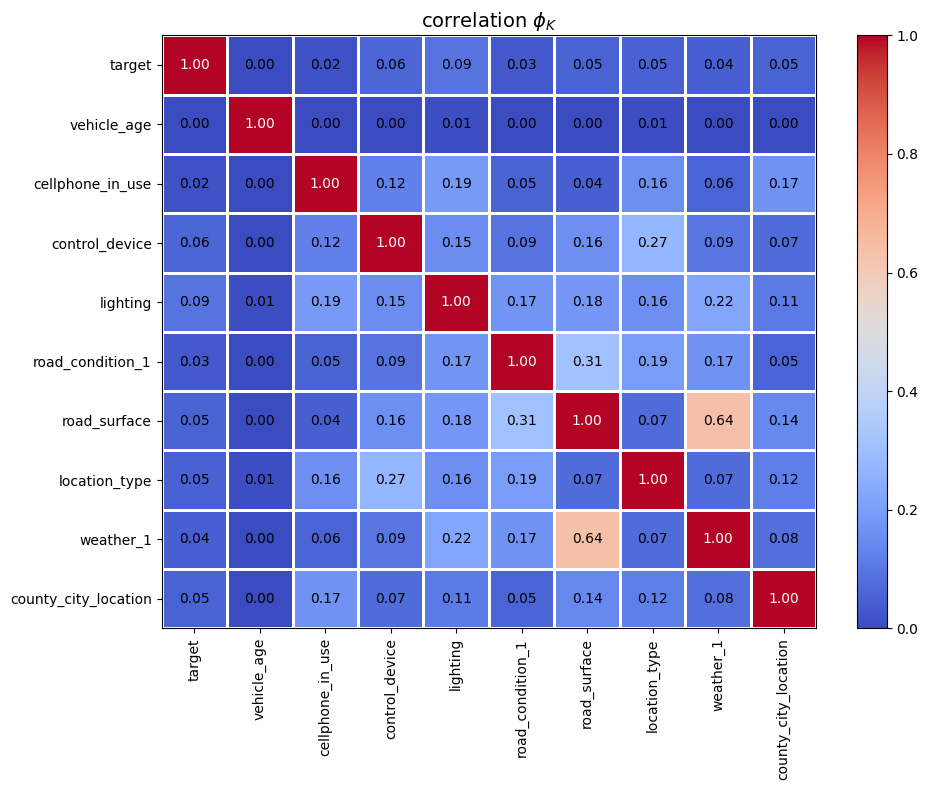

In [25]:
phik_overview = phik_matrix(df)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='coolwarm',
    title=r'correlation $\phi_K$',
    fontsize_factor=1,
    figsize=(10, 8)
)

#### Промежуточный вывод:

В ходе корреляционного анализа выявлено отсутствие мультиколлинеарности с наличием определённой доли зависимости параметров.

В ходе исследования матрицы корреляции `phik_matrix()` мультиколлинеарность и утечка данных не обнаружены.

Также следует отметить, что ни один признак не имеет значительного корреляционного влияния на целевой параметр.


### Подготовка данных к построению модели

Подготовим обучающую и тестовую выборки, проведём масштабирование количественных данных и кодирование категориальных признаков.

In [26]:
# Установка параметров
RANDOM_STATE = 42
TEST_SIZE = 0.25

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis=1),
    df['target'],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [27]:
ohe_columns = ['weather_1', 'location_type', 'road_surface', 'road_condition_1', 'lighting', 'control_device', 'cellphone_in_use']

simp_columns = ['vehicle_age']

In [28]:
# Создание пайплайнов для предобработки
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(drop='first', dtype=np.int32, handle_unknown='ignore'), ohe_columns),  # OHE для категориальных данных
    ('imp', SimpleImputer(strategy='most_frequent'), simp_columns)   # SimpleImputer для обработки пропусков в категориальных данных
])

# Обучение и применение трансформеров
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Получение имен признаков
ohe_columns_transformed = preprocessor.named_transformers_['ohe'].get_feature_names_out(ohe_columns)

# Собираем все имена
feature_names = list(ohe_columns_transformed) + simp_columns

# Преобразуем в плотный формат
X_train_transformed = X_train_transformed.toarray()  # Это уже плотный формат
X_test_transformed = X_test_transformed.toarray()    # Это уже плотный формат

# Преобразование в DataFrame
X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

# Преобразование y_train и y_test в массив NumPy
y_train = y_train.values
y_test = y_test.values

#Удаление выброса в тренировочной выборке, если он попадёт туда
med = X_train_transformed['vehicle_age'].median()
X_train_transformed['vehicle_age'] = X_train_transformed['vehicle_age'].apply(lambda x: med if x == 161 or pd.isna(x) else x)

# Проверим размеры выходных данных
print('Размер обучающей выборки:', X_train_transformed.shape, 'Размер y_train:', y_train.shape)
print('Размер тестовой выборки:', X_test_transformed.shape, 'Размер y_test:', y_test.shape)

#### Промежуточный вывод:

Данные готовы к обучению нейронной сети.

### Создание константной модели

В качестве константной модели можно использовать DummyClassifier.
Для оценки моделей будем применять следующие метрики:


1. Accuracy (Точность):
Описание: Точность (accuracy) — это доля правильно классифицированных экземпляров ко всем экземплярам в наборе данных. Это общее качество модели.

2. Precision (Точность):
Описание: Точность (precision) измеряет, какой процент из предсказанных положительных классов действительно является положительным классом. Это важная метрика, когда увеличение числа ложноположительных (false positives) нежелательно.

3. Recall (Полнота):
Описание: Полнота (recall) измеряет, какой процент настоящих положительных случаев был правильно предсказан моделью. Она показывает способность модели выявлять положительные экземпляры.

4. F1 Score:
Описание: F1 Score — это гармоническое среднее между точностью и полнотой. Это метрика, которая учитывает как ложноположительные, так и ложноотрицательные результаты, и является полезной, когда вам нужно сбалансировать между precision и recall.

5. AUC (Area Under the ROC Curve):
Описание: AUC — это площадь под кривой ROC (Receiver Operating Characteristic), которая показывает, как хорошо модель различает положительные и отрицательные классы. Значение AUC варьируется от 0 до 1.

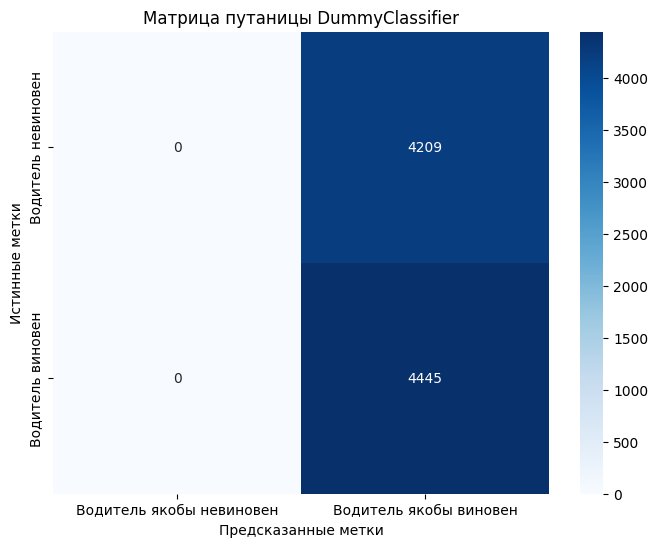

In [29]:
# Создание и обучение DummyClassifier
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_transformed, y_train)

# Получение предсказаний
dummy_predictions = dummy_clf.predict(X_test_transformed)

# Вычисление матрицы путаницы
cm_dummy = confusion_matrix(y_test, dummy_predictions)

# Визуализация матрицы путаницы для DummyClassifier
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Blues', xticklabels=['Водитель якобы невиновен', 'Водитель якобы виновен'], yticklabels=['Водитель невиновен', 'Водитель виновен'])
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.title('Матрица путаницы DummyClassifier')
plt.show()

In [30]:
# Вычисление метрик
accuracy = accuracy_score(y_test, dummy_predictions)
precision = precision_score(y_test, dummy_predictions)
recall = recall_score(y_test, dummy_predictions)
f1 = f1_score(y_test, dummy_predictions)
auc = roc_auc_score(y_test, dummy_predictions)

# Округление до двух знаков
accuracy = round(accuracy, 2)
precision = round(precision, 2)
recall = round(recall, 2)
f1 = round(f1, 2)
auc = round(auc, 2)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'AUC: {auc}')

#### Промежуточный вывод:

Выявлены метрики константной модели.

### Построение базовой нейронной сети

Создадим класс для задания архитектуры нейронной сети. Определим количество скрытых слоёв, количество нейронов на них, функции активации на скрытых и выходном слоях.

Выберем лучшую модель, используя метрику `BCELoss()`.
Данная метрика подходит по нескольким причинам:

* BCEloss подходит для использования в ситуациях, где необходимо получить вероятностные оценки вместо жесткого предсказания классов. Она предоставляет информацию о том, насколько уверена модель в своем предсказании.

* BCEloss считается хорошей метрикой для бинарных классификаторов, так как она работает хорошо с логистическими регрессиями и нейронными сетями, обеспечивая гладкие градиенты, что помогает в обучении.

* BCEloss тесно связана с логистической регрессией, которая является основным методом для бинарной классификации. Использование BCE loss делает её идеальным выбором для оценивания моделей, основанных на логистической функции.

* BCEloss наказывает большие ошибки (например, когда модель уверенно предсказывает неправильный класс), что способствует более быстрому обучению и улучшению качества модели.


In [31]:
# Настройка устройства выполнения (CPU или GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Конвертация в плотный формат перед созданием тензора
X_train_tensor = torch.tensor(X_train_transformed.to_numpy(), dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_transformed.to_numpy(), dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor_ = torch.tensor(y_test, dtype=torch.float32).to(device)

In [32]:
def fit_plot(train_loss, val_loss, abb=0):
    fig = go.Figure()

    # На основе abb выбираем цвет и заголовок
    if abb == 1:
        fig.add_trace(go.Scatter(
            x=np.array(range(len(train_loss))) * 10,  # Эпохи
            y=train_loss,
            name='Тренировка',
            line=dict(color='darkblue', width=3)
        ))
        fig.add_trace(go.Scatter(
            x=np.array(range(len(val_loss))) * 10,
            y=val_loss,
            name='Валидация',
            line=dict(color='crimson', width=3)
        ))
        fig.update_layout(
            width=1000,
            height=500,
            legend_orientation='h',
            title=dict(
                text='Значения функции потерь (BCELoss) при тренировке и тестировании без одного признака',
                x=.5
            ),
            xaxis_title='Эпоха',
            yaxis_title='Функция потерь (BCELoss)'
        )
    else:
        fig.add_trace(go.Scatter(
            x=np.array(range(len(train_loss))) * 10,
            y=train_loss,
            name='Тренировка',
            line=dict(color='darkcyan', width=3)
        ))
        fig.add_trace(go.Scatter(
            x=np.array(range(len(val_loss))) * 10,
            y=val_loss,
            name='Валидация',
            line=dict(color='coral', width=3)
        ))
        fig.update_layout(
            width=1000,
            height=500,
            legend_orientation='h',
            title=dict(
                text='Значения функции потерь (BCELoss) при тренировке и тестировании со всеми признаками',
                x=.5
            ),
            xaxis_title='Эпоха',
            yaxis_title='Функция потерь (BCELoss)'
        )

    fig.show()

Протестируем два типа сетей: с бОльшим и меньшим количеством нейронов. Количество скрытых слоёв одинаковое.

In [33]:
# Определение класса нейронной сети
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_hidden_neurons_3, n_out_neurons):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.bn1 = nn.BatchNorm1d(n_hidden_neurons_1)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3)  # Dropout после первого слоя

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.bn2 = nn.BatchNorm1d(n_hidden_neurons_2)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.3)  # Dropout после второго слоя

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_hidden_neurons_3)
        self.bn3 = nn.BatchNorm1d(n_hidden_neurons_3)
        self.act3 = nn.ReLU()
        self.dropout3 = nn.Dropout(p=0.3)  # Dropout после третьего слоя

        self.fc4 = nn.Linear(n_hidden_neurons_3, n_out_neurons)
        self.act4 = nn.Sigmoid()  # Активация на выходе

        # Инициализация весов
        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in')
        nn.init.normal_(self.fc1.bias, mean=0.5, std=0.7)

        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in')
        nn.init.normal_(self.fc2.bias, mean=0.5, std=0.7)

        nn.init.kaiming_normal_(self.fc3.weight, mode='fan_in')
        nn.init.normal_(self.fc3.bias, mean=0.5, std=0.7)

        nn.init.kaiming_normal_(self.fc4.weight, mode='fan_in')
        nn.init.normal_(self.fc4.bias, mean=0.5, std=0.7)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        x = self.act4(x)  # Применение Sigmoid на выходе
        return x

In [34]:
# определение экземпляров сетей и количества нейронов
n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1_m = 240
n_hidden_neurons_2_m = 120
n_hidden_neurons_3_m = 60
n_hidden_neurons_1_l = 18
n_hidden_neurons_2_l = 8
n_hidden_neurons_3_l = 4
n_out_neurons = 1

net_m = Net(
    n_in_neurons,
    n_hidden_neurons_1_m,
    n_hidden_neurons_2_m,
    n_hidden_neurons_3_m,
    n_out_neurons
    )
net_l = Net(
    n_in_neurons,
    n_hidden_neurons_1_l,
    n_hidden_neurons_2_l,
    n_hidden_neurons_3_l,
    n_out_neurons
    )

loss = nn.BCELoss()

num_epochs = 100000
learning_rate = 5e-3

# создание списков для дальнейшего отображения графиков
train_loss_m = []
test_metric_m = []

train_loss_l = []
test_metric_l = []

In [35]:
def fit(
    net,
    optimizer, loss,
    train_loss,
    val_metric,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor,
    num_epochs, patience=1, max_delta=10
):
    counter = 0
    min_val_metric = np.inf

    # Цикл по эпохам
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = net(X_train_tensor)
        preds = torch.sigmoid(preds)
        loss_value = loss(preds, y_train_tensor)
        loss_value.backward()
        optimizer.step()

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            train_loss.append(loss_value.item())

            net.eval()  # переключаем модель в режим оценки
            with torch.no_grad():
                val_preds = net(X_val_tensor)
                val_preds = torch.sigmoid(val_preds)
                val_loss_value = loss(val_preds, y_val_tensor)
                val_metric.append(val_loss_value.item())

                if val_loss_value < min_val_metric:
                    min_val_metric = val_loss_value
                    counter = 0
                else:
                    counter += 1

                if counter >= patience or (val_loss_value - min_val_metric >= max_delta):
                    print(f'Early stopping at epoch {epoch} due to no improvement.')
                    break

In [36]:
# Кросс-валидация
kf = KFold(n_splits=5)
val_losses_m = []  # Список для хранения значений валидационных потерь модели m
val_losses_l = []  # Список для хранения значений валидационных потерь модели l

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_tensor)):
    print(f'Fold {fold + 1}')

    # Данные для текущего fold
    X_train_tensor_cv = X_train_tensor[train_idx]
    y_train_tensor_cv = y_train_tensor[train_idx]
    X_val_tensor_cv = X_train_tensor[val_idx]
    y_val_tensor_cv = y_train_tensor[val_idx]

    # Экземпляры моделей
    net_m = Net(n_in_neurons, n_hidden_neurons_1_m, n_hidden_neurons_2_m, n_hidden_neurons_3_m, n_out_neurons).to(device)
    net_l = Net(n_in_neurons, n_hidden_neurons_1_l, n_hidden_neurons_2_l, n_hidden_neurons_3_m, n_out_neurons).to(device)

    # Оптимизаторы
    optimizer_m = torch.optim.Adamax(net_m.parameters(), lr=learning_rate, weight_decay=0.001)
    optimizer_l = torch.optim.Adamax(net_l.parameters(), lr=learning_rate, weight_decay=0.001)

    # Функция потерь
    loss_function = nn.BCELoss()  # Имя вашей функции потерь

    # Списки для хранения значений потерь
    train_loss_m = []
    val_metric_m = []

    train_loss_l = []
    val_metric_l = []


    fit(
        net_m,
        optimizer_m,
        loss_function,
        train_loss_m,
        val_metric_m,
        X_train_tensor_cv,
        y_train_tensor_cv,
        X_val_tensor_cv,
        y_val_tensor_cv,
        num_epochs=num_epochs  # Явное указание здесь корректно
    )

    fit(
        net_l,
        optimizer_l,
        loss_function,
        train_loss_l,
        val_metric_l,
        X_train_tensor_cv,
        y_train_tensor_cv,
        X_val_tensor_cv,
        y_val_tensor_cv,
        num_epochs=num_epochs  # Явное указание здесь корректно
    )

    # Вывод результатов для текущего fold
    train_loss_m_last = round(train_loss_m[-1], 2)
    val_metric_m_last = round(val_metric_m[-1], 2)
    train_loss_l_last = round(train_loss_l[-1], 2)
    val_metric_l_last = round(val_metric_l[-1], 2)

    val_losses_m.append(val_metric_m_last)
    val_losses_l.append(val_metric_l_last)

    print(f'Fold {fold + 1} results:')
    print(f'Model m - Train Loss: {train_loss_m_last}, Validation Loss: {val_metric_m_last}')
    print(f'Model l - Train Loss: {train_loss_l_last}, Validation Loss: {val_metric_l_last}')

# Нахождение средней валидационной метрики по всем fолдам
average_val_loss_m = round(np.mean(val_losses_m), 2)
average_val_loss_l = round(np.mean(val_losses_l), 2)

print(f'Average Validation Loss for Model m: {average_val_loss_m}')
print(f'Average Validation Loss for Model l: {average_val_loss_l}')

In [37]:
# просмотр процесса обучения сетей с большим количеством нейронов
fit_plot(train_loss_m, val_metric_m)


In [38]:
# просмотр процесса обучения сетей с меньшим количеством нейронов
fit_plot(train_loss_l, val_metric_l)


In [39]:
# Сравнение наилучших метрик (BCELoss) разных сетей на валидации
# Подсчет и вывод наименьшего значения BCELoss для сети с большим количеством нейронов и всем признаками
print(
    'Наименьшая BCELoss сети с большим количеством нейронов —',
    round(np.min(average_val_loss_m ), 2),  # Округление до двух знаков
)

# Подсчет и вывод наименьшего значения BCELoss для сети с меньшим количеством нейронов и всем признаками
print(
    'Наименьшая BCELoss сети с меньшим количеством нейронов —',
    round(np.min(average_val_loss_l ), 2),  # Округление до двух знаков
)

Качество у сети с меньшим количеством нейронов выше.

### Модель RandomForestClassifier()

Создадим модель RandomForestClassifier() с кросс-валидацией и подбором гиперпараметров.

In [40]:
# Определение параметров для подбора
param_grid = {
    'n_estimators': [50, 100],  # Количество деревьев
    'max_depth': [10, 20],  # Максимальная глубина дерева
    'min_samples_split': [2, 5],  # Минимальное количество образцов для разбиения узла
    'min_samples_leaf': [1, 2]  # Минимальное количество образцов в листе
}

# Инициализация модели дерева решений
rf = RandomForestClassifier(random_state=42)

# Инициализация GridSearchCV для подбора гиперпараметров
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=1, verbose=2,
                           scoring='neg_log_loss')  # Изменено на neg_log_loss

# Выполнение подбора гиперпараметров
grid_search.fit(X_train_transformed, y_train)  # Преобразование тензоров в NumPy

# Получение наилучших параметров
best_params = grid_search.best_params_
print("Наилучшие гиперпараметры:", best_params)

# Оценка модели с наилучшими параметрами
best_rf = grid_search.best_estimator_
# Обратное значение, так как мы используем neg_log_loss
cv_scores = cross_val_score(best_rf, X_train_transformed, y_train, cv=5, scoring='neg_log_loss')
mean_log_loss = -cv_scores.mean() # Преобразование обратно в положительное значение
print("Средняя величина логистической потери (BCELoss) кросс-валидации:", round(mean_log_loss, 2))

#### Промежуточный вывод:

Метрика BCELoss одинаковая у обеих моделей. Возьмем в работу `RandomForestClassifier()`.

### "Матрица ошибок"

Построим график "Матрица ошибок", наглядно показывающий разницу между действительными и предсказанными наилучшей на данный момент модели. Так как нам важнее всего предотвратить аварию по вине водителя, снизим порог предсказания.

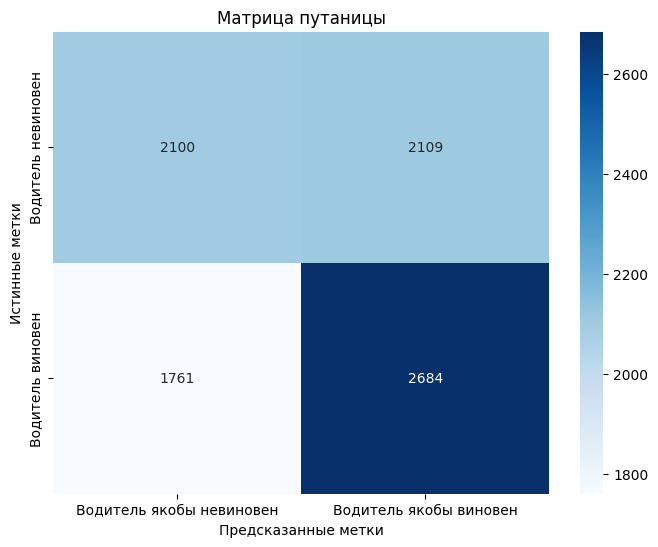

In [41]:
# получение предсказаний
test_predictions = best_rf.predict_proba(X_test_transformed)[:, 1]

# Преобразование вероятностей в метки (0 или 1)
y_pred = (test_predictions >= 0.5).astype(int)
#y_pred = y_pred_optimal

# Вычисление матрицы путаницы
cm = confusion_matrix(y_test, y_pred)

# Визуализация матрицы путаницы
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Водитель якобы невиновен', 'Водитель якобы виновен'], yticklabels=['Водитель невиновен', 'Водитель виновен'])
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.title('Матрица путаницы')
plt.show()

In [42]:
# Вычисление метрик
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

# Округление до двух знаков
accuracy = round(accuracy, 2)
precision = round(precision, 2)
recall = round(recall, 2)
f1 = round(f1, 2)
auc = round(auc, 2)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'AUC: {auc}')

#### Промежуточный вывод:

1. Accuracy (Точность): 0.55
Значение 0.55 (или 55%) указывает, что 56% всех экземпляров были правильно классифицированы моделью. Это значение считается достаточно низким, особенно если у вас сбалансированные классы. Важно учитывать, что высокая accuracy может быть обманчивой, если классы несбалансированы.

2. Precision (Точность): 0.56
Значение 0.56 (или 56%) означает, что когда модель предсказывает положительный класс, она оказывается правильной только в 58% случаев. Это может указывать на проблему с ложными срабатываниями, что может быть значительным недостатком в задачах, где ложные положительные результаты имеют серьезные последствия (например, в медицине).

3. Recall (Полнота): 0.6
Значение 0.6 (или 60%) означает, что модель может корректно обнаружить 60% положительных экземпляров в выборке. Это указывает на то, что модель довольно хорошо справляется с обнаружением положительных классов, но все еще упускает некоторые экземпляры.

4. F1 Score: 0.58
Значение 0.58 (или 58%) указывает на общий баланс между Precision и Recall. F1 Score варьируется от 0 до 1, и значение, близкое к 0.6, говорит о том, что модель имеет ряд проблем и нуждается в доработках. Это значение подходит для сценариев, где важно уравновесить количество ложных срабатываний и пропусков.

5. AUC (ROC AUC): 0.55
Значение 0.55 указывает на очень слабую производительность модели, близкую к случайному выбору (0.5). Это говорит о том, что модель не может хорошо различать положительные и отрицательные классы, что является серьезным недостатком.

Общая оценка:
В целом, все метрики указывают на то, что модель в текущем состоянии имеет низкую производительность. **Тем не менее, метрика Recall выше, чем остальные. Это полезно в нашем случае, где важно обнаружить как можно больше положительных экземпляров (ДТП по вине водителя). **

### Анализ важности признаков:

Оценим важность признаков для лучшей модели и построим графики важности с помощью метода SHAP.

In [43]:
# Создание объяснителя SHAP для RandomForest
explainer = shap.TreeExplainer(best_rf)

# Получение значений SHAP для тестовых данных
shap_values = explainer.shap_values(X_test_transformed)

In [44]:
# Выбираем значения SHAP для нужного класса (например, класс 1)
shap_values_class_1 = shap_values[:, :, 1]  # Выбор значений SHAP для класса с индексом 1

# Проверяем размеры
print("SHAP values shape:", shap_values_class_1.shape)  # Должно быть (15001, 670)
print("Input data shape:", X_test_transformed.shape)    # Должно быть (15001, 670)

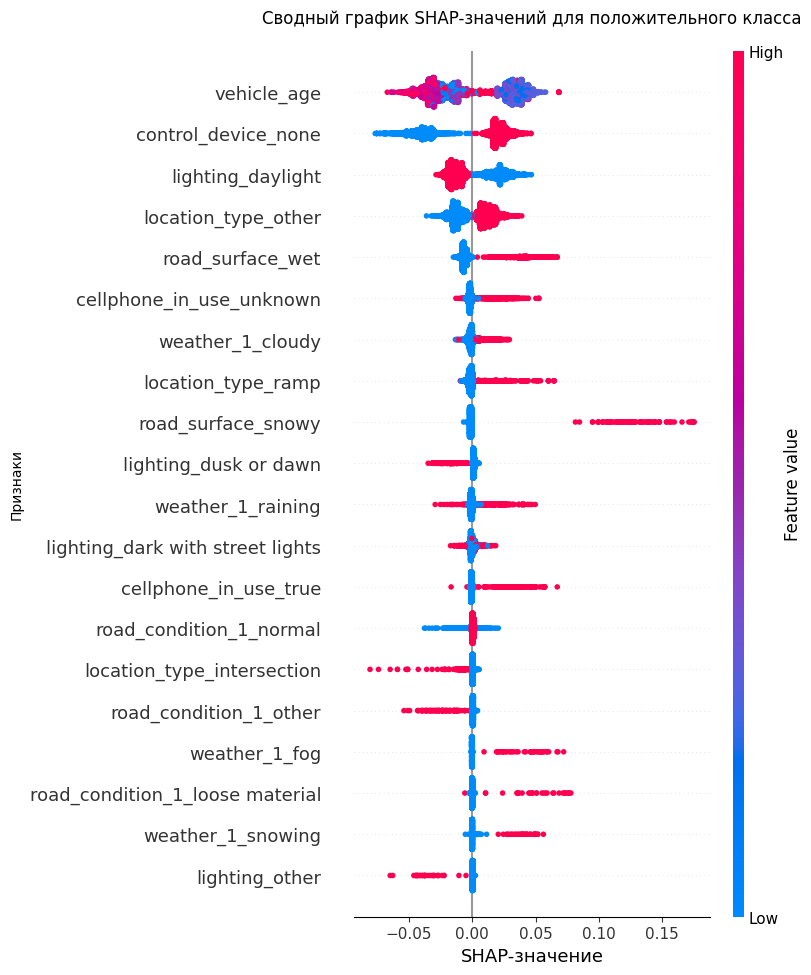

In [45]:
# Визуализация значений SHAP без отображения графика сразу
shap.summary_plot(shap_values_class_1, X_test_transformed, feature_names=feature_names, show=False)

# Добавление заголовка и подписей к осям на русском языке с отступом
plt.title("Сводный график SHAP-значений для положительного класса", pad=20)
plt.xlabel("SHAP-значение")
plt.ylabel("Признаки")

# Отображение графика
plt.show()

#### Промежуточный вывод:

Самые важные факторы для определения вероятности того, что водитель будет причиной аварии — возраст автомобиля `vehicle_age`, отсутствие контролирующего устройства `control_device`, состоние дороги (влажность, снег), отсутствие громкой связи для телефона.



In [46]:
pvt = pd.pivot_table(df, index='target', columns='vehicle_age', aggfunc='size')
pvt.rename(index={0: "ДТП не по вине водителя", 1: "ДТП по вине водителя"}, inplace=True)
pvt

In [47]:
# Создание субграфиков
fig = make_subplots(
    rows=1,
    cols=len(pvt.index),
    specs=[[{'type': 'pie'}] * len(pvt.index)],
    subplot_titles=pvt.index
)

# Добавление круговых диаграмм для каждой категории
for i, target in enumerate(pvt.index):
    values = pvt.loc[target]
    total_count = values.sum()  # Общая сумма значений

    # Сортируем значения по убыванию
    sorted_values = values.sort_values(ascending=False)
    sorted_labels = sorted_values.index

    fig.add_trace(go.Pie(
        labels=sorted_labels,
        values=sorted_values,
        name=target,
        textinfo='percent',  # Отображаем только проценты
        pull=[0.1, 0],  # Выдвигает первую секцию (трезвые) для акцента
        sort=True,  # Сортировка секторов
        direction='clockwise'  # Положение секторов по часовой стрелке
    ), row=1, col=i + 1)

    # Добавление аннотации снизу диаграммы с фиксированными координатами
    fig.add_annotation(
        x=i + 1,  # Позиция по оси x, колонка i + 1
        y=-0.12,  # Позиция по оси y (поставим ниже)
        text=f"Количество значений: {total_count}",
        showarrow=False,
        font=dict(size=12),
        xref='x',  # Оси X
        yref='paper'  # Используем 'paper' для позиционирования
    )

# Настройка общего заголовка, расположения легенды и скрытие осей
fig.update_layout(
    title_text="Соотношение сроков службы автомобилей по виновнику ДТП",
    title_x=0.5,  # Центрируем заголовок
    height=1100,  # Задаем высоту, чтобы было больше места для подписей
    width=1000,  # Задаем ширину, чтобы большие диаграммы поместились
    margin=dict(t=50, b=150, l=50, r=50),  # Настройка отступов для улучшения области графиков
    legend=dict(x=0.5, y=-0.2, xanchor='center', yanchor='top', orientation='h')  # Позиционируем легенду снизу
)

# Показываем график
fig.show()

По графикам видно, что в ДТП, которые произошли по вине водителя, доля автомобилей со сроком службы 2-5 лет составила **>55%**. В ДТП, произошедших не по вине водителя, доля таких машин меньше - 45%.

Необходимо дополнительно проанализировать, какое количество ДТП непосредственно связано с технической неисправностью автомобилей, т.к. 2-5 лет эксплуатации - малый срок для серьёзных поломок. Если же доля тех.причин высока, необходимо обеспечивать своевременное ТО, подключение систем анализа состояния с передачей информации в режиме он-лайн на серверы, в диспетчерскую.

In [48]:
pvt = pd.pivot_table(df, index='target', columns='control_device', aggfunc='size')
pvt.rename(index={0: "ДТП не по вине водителя", 1: "ДТП по вине водителя"}, inplace=True)
pvt

In [49]:
# Создание субграфиков
fig = make_subplots(
    rows=1,
    cols=len(pvt.index),
    specs=[[{'type': 'pie'}] * len(pvt.index)],
    subplot_titles=pvt.index
)

# Добавление круговых диаграмм для каждой категории
for i, target in enumerate(pvt.index):
    values = pvt.loc[target]
    total_count = values.sum()  # Общая сумма значений

    # Сортируем значения по убыванию
    sorted_values = values.sort_values(ascending=False)
    sorted_labels = sorted_values.index

    fig.add_trace(go.Pie(
        labels=sorted_labels,
        values=sorted_values,
        name=target,
        textinfo='percent',  # Отображаем только проценты
        pull=[0.1, 0],  # Выдвигает первую секцию (трезвые) для акцента
        sort=True,  # Сортировка секторов
        direction='clockwise'  # Положение секторов по часовой стрелке
    ), row=1, col=i + 1)

    # Добавление аннотации снизу диаграммы с фиксированными координатами
    fig.add_annotation(
        x=i + 1,  # Позиция по оси x, колонка i + 1
        y=-0.12,  # Позиция по оси y (поставим ниже)
        text=f"Количество значений: {total_count}",
        showarrow=False,
        font=dict(size=12),
        xref='x',  # Оси X
        yref='paper'  # Используем 'paper' для позиционирования
    )

# Настройка общего заголовка, расположения легенды и скрытие осей
fig.update_layout(
    title_text="Соотношение наличия/отсутствия устройства управления по виновнику ДТП",
    title_x=0.5,  # Центрируем заголовок
    height=900,  # Задаем высоту, чтобы было больше места для подписей
    width=1000,  # Задаем ширину, чтобы большие диаграммы поместились
    margin=dict(t=50, b=150, l=50, r=50),  # Настройка отступов для улучшения области графиков
    legend=dict(x=0.5, y=-0.2, xanchor='center', yanchor='top', orientation='h')  # Позиционируем легенду снизу
)

# Показываем график
fig.show()

По графикам видно, что в ДТП, которые произошли по вине водителя, доля отсутствия устройств контроля выше на **~5%**.

Для нивелирования данного фактора необходимо оборудовать максимально возможное количество автомобилей данными устройствами.

### Общий вывод:

**Описание проекта:**

Вы — специалист по Data Science в каршеринговой компании. Вам поступил заказ: нужно создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения. Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.
Идея создания такой системы находится в стадии предварительного обсуждения и проработки. Чёткого алгоритма работы и подобных решений на рынке ещё не существует.

**Текущая задача** — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

**Идея решения задачи от заказчика:**

    Создать модель предсказания ДТП (целевое значение — at_fault (виновник) в таблице parties)
     
        Для модели выбрать тип виновника — только машина (car).
        Выбрать случаи, когда ДТП привело к любым повреждениям транспортного средства, кроме типа SCRATCH (царапина).
        Для моделирования ограничиться данными за 2012 год — они самые свежие.
        Обязательное условие — учесть фактор возраста автомобиля.
    На основе модели исследовать основные факторы ДТП.
    Понять, помогут ли результаты моделирования и анализ важности факторов ответить на вопросы:
     
        Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
        Какие ещё факторы нужно учесть?
        Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?

Заказчик предлагает вам поработать с базой данных по происшествиям и сформировать свои идеи создания такой системы.

В ходе работы осуществлено подключение к БД, были сделаны следующие выводы:

* количество таблиц соответствует условию задачи;
* все таблицы имеют набор данных;
* имеется общий ключ для связи таблиц - `case_id` в таблице `case_ids`.

**Проведён статистический анализ факторов ДТП:** наибольшее количество аварий происходит в марте, январе, мае, апреле и феврале.
Вероятно, это связано с погодными условиями (снег, гололёд), праздниками (вождение в нетрезвом виде).

**Подготовлены аналитические задачи для коллег:**

1. Проведите анализ серьёзности повреждений транспортного средства, исходя из трезвости участника ДТП (связать collisions и parties);
2. Проведите анализ серьёзности повреждений транспортного средства, исходя из типа кузова автомобиля (связать collisions и vehicles);
3. По каким регионам наблюдается больше аварий, а по каким - меньше (таблица collisions);
4. По каким категориям нарушения наблюдается больше аварий, а по каким - меньше (таблица collisions);
5. Проведите анализ серьёзности повреждений транспортного средства, исходя из возраста автомобиля (связать collisions и vehicles);
6. Проведите анализ физического состояния и трезвости участника ДТП (таблица parties).

Первые две задачи решены с помощью SQL-запросов.

**Созданы модели для оценки водительского риска.**

Подготовлен набор данных на основе первичного предположения заказчика:
     
    Тип виновника — только машина (car).
    Случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников — все, кроме типа SCRATCH (царапина).
    Для моделирования возьмём данные только за 2012 год.
    Подготовка исходной таблицы должна проводиться с помощью sql-запроса.

Проведён первичный отбор факторов, необходимых для модели: нужно отобрать те, которые могут влиять на вероятность ДТП.

Таблица `collisions`: маловажные факторы, которые вряд ли подойдут для модели:

* Расстояние от главной дороги (метры)	`DISTANCE` - ДТП может произойти где угодно;
* Направление движения	`DIRECTION` - стороны света также не влияют на вероятность ДТП;
* Количество участников	`PARTY_COUNT`, Тип аварии	`TYPE_OF_COLLISION`, Дополнительные участники ДТП	`MOTOR_VEHICLE_INVOLVED_WITH`, Категория нарушения	`PCF_VIOLATION_CATEGORY`, Основной фактор аварии	`PRIMARY_COLL_FACTOR` - эти признаки - следствие ДТП, а не причина. Они могут привести к утечке данных;
* Серьёзность происшествия	`COLLISION_DAMAGE` - аргумент тот же, но этот признак необходим при создании SQL-запроса.

Важные факторы:

* Является ли место происшествия перекрёстком	`INTERSECTION`, Тип дороги	`LOCATION_TYPE` - при построении маршрута модель может проанализировать количество перекрёстков, по каким дорогам проложен путь. Если ранее на данных участках было много ДТП, возможно увеличение вероятности нового происшествия;
* Погода	`WEATHER_1`, Состояние дороги	`ROAD_SURFACE`, Освещение	`LIGHTING`, Дорожное состояние	`ROAD_CONDITION_1` - погодные факторы, освещение и факторы состояния дорожного полотна являются критически важными для предсказания вероятности ДТП.

Факторы, влияние которых надо проверять:

* Номер географических районов, где произошло ДТП	`COUNTY_CITY_LOCATION`	и Названия географических районов, где произошло ДТП	`COUNTY_LOCATION` - возможно, есть регионы с повышенным риском образования ДТП;
* Устройство управления	`CONTROL_CONDITION_1` - невозможно на данный момент сказать, что это за устройство, какие у него функции.


---

---


Таблица `parties`. Маловажные факторы, которые вряд ли подойдут для модели:

* Тип участника происшествия	`PARTY_TYPE` - признак необходим при создании SQL-запроса, но при использовании приведёт к утечке данных.
* Сумма страховки  `INSURANCE_PREMIUM` - в данном проекте мы не предсказываем суммы страховок.

Важные факторы, которые приведут к утечке:
* Трезвость участника	`PARTY_SOBRIETY`, Состояние участника `PARTY_DRUG_PHYSICAL` - эти факторы могут сыграть огромную роль в возникновении опасности, создать аварийную ситуацию. Но, мы не можем заранее знать состояние водителя, поэтому обучать модели на данных фичах некорректно.

Фактор, который можно взять для обучения модели:
* Наличие телефона в автомобиле (возможности разговаривать по громкой связи)	`CELLPHONE_IN_USE` - отвлечение внимания водителя тоже зачастую приводит к ДТП.


---


Из таблицы `vehicles` пододящий признак только один - Возраст автомобиля `VEHICLE_AGE`. Чем старше авто, тем больше вероятность поломки и аварии. К тому же, необходимо учесть этот параметр - таково обязательное условие заказчика.

**После выгрузки данных был проведён EDA-анализ.**

В ходе EDA выявлено:

* присутствуют полные дубликаты, устраним их;
* в данных есть пропуски и нулевые значения, далее заполним их по смысловому значению (нулями, медианными значениями, наиболее частыми значениями или заглушками и т.д.);
* по некоторым столбцам наблюдается дисбаланс данных (доля одного значения может составлять 50-90%).

Данные очищены от дубликатов, пропусков в данных.

**В ходе корреляционного анализа** выявлено отсутствие мультиколлинеарности с наличием определённой доли зависимости параметров.

В ходе исследования матрицы корреляции `phik_matrix()` мультиколлинеарность и утечка данных не обнаружены.

**Также следует отметить, что ни один признак не имеет значительного корреляционного влияния на целевой параметр.**

Подготовлены обучающая и тестовая выборки, проведено масштабирование количественных данных и кодирование категориальных признаков с помощью пайплайна.

Для сравнения метрик создана константная модель `DummyClassifier`.

Для оценки моделей применены следующие метрики:

1. Accuracy (Точность):
Описание: Точность (accuracy) — это доля правильно классифицированных экземпляров ко всем экземплярам в наборе данных. Это общее качество модели.

2. Precision (Точность):
Описание: Точность (precision) измеряет, какой процент из предсказанных положительных классов действительно является положительным классом. Это важная метрика, когда увеличение числа ложноположительных (false positives) нежелательно.

3. Recall (Полнота):
Описание: Полнота (recall) измеряет, какой процент настоящих положительных случаев был правильно предсказан моделью. Она показывает способность модели выявлять положительные экземпляры.

4. F1 Score:
Описание: F1 Score — это гармоническое среднее между точностью и полнотой. Это метрика, которая учитывает как ложноположительные, так и ложноотрицательные результаты, и является полезной, когда вам нужно сбалансировать между precision и recall.

5. AUC (Area Under the ROC Curve):
Описание: AUC — это площадь под кривой ROC (Receiver Operating Characteristic), которая показывает, как хорошо модель различает положительные и отрицательные классы. Значение AUC варьируется от 0 до 1.

Создан класс для задания архитектуры нейронной сети. Определено количество скрытых слоёв, количество нейронов на них, функции активации на скрытых и выходном слоях. Добавлена кросс-валидация.

Выбрана лучшая модель с использованием метрики `BCELoss()`.

**Проведено обучение лучшей модели, качество у сети с меньшим количеством нейронов выше.**

Также была обучена модель `RandomForestClassifier()` с кросс-валидацией и подбором гиперпараметров.

**По итогу эксперимента выбор сделан в пользу `RandomForestClassifier()`.**

Для тетовых предсказаний была построена матрица ошибок, найдены основные метрики:

1. Accuracy (Точность): 0.55

Значение 0.55 (или 55%) указывает, что 56% всех экземпляров были правильно классифицированы моделью. Это значение считается достаточно низким, особенно если у вас сбалансированные классы. Важно учитывать, что высокая accuracy может быть обманчивой, если классы несбалансированы.

2. Precision (Точность): 0.56

Значение 0.56 (или 56%) означает, что когда модель предсказывает положительный класс, она оказывается правильной только в 58% случаев. Это может указывать на проблему с ложными срабатываниями, что может быть значительным недостатком в задачах, где ложные положительные результаты имеют серьезные последствия (например, в медицине).

3. Recall (Полнота): 0.6

Значение 0.6 (или 60%) означает, что модель может корректно обнаружить 60% положительных экземпляров в выборке. Это указывает на то, что модель довольно хорошо справляется с обнаружением положительных классов, но все еще упускает некоторые экземпляры.

4. F1 Score: 0.58

Значение 0.58 (или 58%) указывает на общий баланс между Precision и Recall. F1 Score варьируется от 0 до 1, и значение, близкое к 0.6, говорит о том, что модель имеет ряд проблем и нуждается в доработках. Это значение подходит для сценариев, где важно уравновесить количество ложных срабатываний и пропусков.

5. AUC (ROC AUC): 0.55

Значение 0.55 указывает на очень слабую производительность модели, близкую к случайному выбору (0.5). Это говорит о том, что модель не может хорошо различать положительные и отрицательные классы, что является серьезным недостатком.

Общая оценка:
В целом, все метрики указывают на то, что модель в текущем состоянии имеет низкую производительность. **Тем не менее, метрика Recall выше, чем остальные. Это полезно в нашем случае, где важно обнаружить как можно больше положительных экземпляров (ДТП по вине водителя). **

**Оценена важность признаков для лучшей модели и построены графики важности с помощью метода SHAP:** самые важные факторы для определения вероятности того, что водитель будет причиной аварии — возраст автомобиля `vehicle_age`, отсутствие контролирующего устройства `control_device`, состоние дороги (влажность, снег), отсутствие громкой связи для телефона.

По графикам видно, что в ДТП, которые произошли по вине водителя, доля автомобилей со сроком службы 2-5 лет составила **>55%**. В ДТП, произошедших не по вине водителя, доля таких машин меньше - 45%.

Необходимо дополнительно проанализировать, какое количество ДТП непосредственно связано с технической неисправностью автомобилей, т.к. 2-5 лет эксплуатации - малый срок для серьёзных поломок. Если же доля тех.причин высока, необходимо обеспечивать своевременное ТО, подключение систем анализа состояния с передачей информации в режиме он-лайн на серверы, в диспетчерскую.

По графикам видно, что в ДТП, которые произошли по вине водителя, доля отсутствия устройств контроля выше на **~5%**.

Для нивелирования данного фактора необходимо оборудовать максимально возможное количество автомобилей данными устройствами.

**Также необходимо отметить тот факт, что с текущим набором данных, значение которых мы можем знать заранее перед прогнозом виновника ДТП, нет возможности как следует обучить модели.** Необходимы дополнительные меры для наполнения базы данных.

Ещё, например, очень много ДТП совершаются в состоянии алкогольного опьянения, усталости. Так как предугадать состояние водителя мы не в силах, то можно сделать следующие мероприятия:

* оборудовать автомобиль анализатором алкогольного опьянения. Измерение состояния при посадке сделать обязательным условием допуска за руль;
* чтобы убедиться, что в трубку дышит именно водитель, добавить камеру, направленную на водительское место;
* оборудовать автомобиль видеоаналитикой, которая позволяет фиксировать частоту морганий глаз, отвлечение внимания от дороги, рассеянность;
* в случве обнаружения подобных случаев - рассмотреть возможность принудительной безопасной остановки авто, передачи сигнала сотрудникам ГАИ, чтобы они проверили водителя.
